# Cost Resource Curves

Fitting of cost resource curves by country. Data for potentials are provided by:

- Tröndel, T., S. Pfenninger, and J. Lilliestam (2019): Home-made or imported: On the possibility for renewable electricity autarky on all scales in Europe". Energy Strategy Reviews 26, 100388. 
- Data are online available under: https://zenodo.org/record/3244985#.YJp_AIfwjg4

Cost data taken from: 

We use data on the municipality level to capture the spatial heterogeneity of resource potentials. Moreover we use technical potentials corrected for social constraints.

To run the code, extract the zip file to the source_data folder

jab 22.03.2019
update: 11.05.2021

## Packages and options

In [5]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [18]:
fn_out = ""
dir_source = "../source_data/cost_resources_curves/municipal/technical-social-potential/"
fn_potential = dir_source + "potentials.csv"
fn_capacity = dir_source + "capacities.csv"
fn_units = "../source_data/cost_resources_curves/municipal/units.csv"
fn_cost = "../source_data/costs_resource_curves/investment_cost.xlsx"
fn_out = "../parsed_data/cost_resource_curves.csv"
dir_figures = "../figures/"

Dictionary for technology aggregation

**NOTE** this has to be consistent with the one used in parse generation

In [9]:
dict_agg_tech = {"Other": "Other",
                "Wind Offshore": "WindOffshore",
                "Fossil Brown coal/Lignite": "Lignite",
                "Nuclear": "Nuclear",
                "Fossil Hard coal": "HardCoal",
                "Geothermal": "Other",
                "Fossil Coal-derived gas": "Other",
                "Hydro Pumped Storage": "Pump",
                "Hydro Run-of-river and poundage": "RunOfRiver",
                "Biomass": "Biomass",
                "Fossil Peat": "Other",
                "Fossil Oil shale": "Oil",
                "Fossil Oil": "Oil",
                "Hydro Water Reservoir": "Reservoir",
                "Marine": "Other",
                "Wind Onshore": "WindOnshore",
                "Other renewable": "Other",
                "Solar": "Solar",
                "Waste": "Other",
                "Fossil Gas": "Gas",
                "rooftop_pv" : "Solar",
                "onshore_wind" : "WindOnshore",
                "offshore_wind" : "WindOffshore"}

## Load data

List of all municipalities:

In [10]:
df_units = pd.read_csv(fn_units).drop(["type", "proper"], axis=1)
#df_units

Renewable potential by technology and municipality:

In [11]:
df_pot_in = pd.read_csv(fn_potential).merge(df_units, on="id")
df_pot_in = df_pot_in.melt(["id", "country_code", "name"])
df_pot_in.variable = df_pot_in.variable.map(lambda x: x.replace("_twh_per_year", ""))
df_pot = df_pot_in.rename(columns={"variable": "technology", "value": "twh"})
df_pot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490540 entries, 0 to 490539
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            490540 non-null  object 
 1   country_code  490540 non-null  object 
 2   name          490536 non-null  object 
 3   technology    490540 non-null  object 
 4   twh           490504 non-null  float64
dtypes: float64(1), object(4)
memory usage: 18.7+ MB


In [12]:
df_cap_in = pd.read_csv(fn_capacity)
df_cap_in = df_cap_in.melt(["id"])
df_cap_in.variable = df_cap_in.variable.map(lambda x: x.replace("_mw",""))
df_cap = df_cap_in.rename(columns={"variable": "technology", "value": "mw"})
df_cap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490540 entries, 0 to 490539
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          490540 non-null  object 
 1   technology  490540 non-null  object 
 2   mw          490504 non-null  float64
dtypes: float64(1), object(2)
memory usage: 11.2+ MB


Merge data together. In merging, we drop entries for which either the capacity or the potential is zero.

In [13]:
df_twh_mw = df_pot.merge(df_cap, on=["id", "technology"])
df_twh_mw = df_twh_mw[(df_twh_mw.mw.notnull()) & (df_twh_mw.twh.notnull())].copy()
df_twh_mw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490504 entries, 0 to 490539
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            490504 non-null  object 
 1   country_code  490504 non-null  object 
 2   name          490500 non-null  object 
 3   technology    490504 non-null  object 
 4   twh           490504 non-null  float64
 5   mw            490504 non-null  float64
dtypes: float64(2), object(4)
memory usage: 26.2+ MB


Add fullload hours

In [14]:
df_twh_mw["fullload_hours"] = df_twh_mw.twh*1000000/df_twh_mw.mw

Get investment cost and calculate annualized investment cost

In [68]:
# 1. Load data
df_inv_in = pd.read_excel(fn_cost, sheet_name="data", index_col=0)

# 2. Transpose the data so technologies are rows (index) 
# and 'inv_cost', 'lifetime', etc., are columns.
df_tech = df_inv_in.T 

# 3. Calculate the Annuity (euro_mw) using Vectorization (No nested loops needed!)
# Formula: (CapEx * interest) / (1 - exp(-interest * lifetime))
# We multiply by 1000 to convert Euro/kw to Euro/mw
interest = df_tech["interest"]
lifetime = df_tech["lifetime"]
capex_mw = df_tech["inv_cost [Euro/kw]"] * 1000

df_tech["euro_mw"] = (capex_mw * interest) / (1 - np.exp(-interest * lifetime))

# 4. Convert back to your original format (Parameters as rows, Tech as columns)
df_inv_in = df_tech.T

print(df_inv_in)

                    rooftop_pv  onshore_wind  offshore_wind
inv_cost [Euro/kw]    800.0000   1500.000000    3100.000000
lifetime               25.0000     20.000000      20.000000
interest                0.0210      0.025000       0.048000
euro_mw             41131.6456  95306.028095  241125.076374


Filter to get only cost 

In [88]:
df_inv_cost = pd.DataFrame(df_inv_in).loc[[("euro_mw")]].T
df_inv_cost

,euro_mw
rooftop_pv,41131.645600
onshore_wind,95306.028095
offshore_wind,241125.076374


Make a frame with all data including cost

In [89]:
df_all = df_twh_mw.merge(df_inv_cost, left_on="technology", right_index=True)

In [90]:
df_all.head()

,id,country_code,name,technology,twh,mw,fullload_hours,euro_mw
0,AT10101,AUT,Eisenstadt,rooftop_pv,0.187516,174.309906,1075.761887,41131.6456
1,AT10201,AUT,Rust,rooftop_pv,0.038477,35.854127,1073.160752,41131.6456
2,AT10301,AUT,Breitenbrunn am Neusiedler See,rooftop_pv,0.039337,36.822629,1068.273560,41131.6456
3,AT10302,AUT,Donnerskirchen,rooftop_pv,0.027742,25.968702,1068.273560,41131.6456
4,AT10303,AUT,Großhöflein,rooftop_pv,0.037916,35.141224,1078.952333,41131.6456


## Plot fulload hours for each country

In [91]:
mpl.rcParams["font.size"] = 40
mpl.rcParams["figure.figsize"] = (40,20)

In [92]:
lst_tech = list(df_twh_mw.technology.unique())
lst_countries = list(df_twh_mw.country_code.unique())
#lst_tech, lst_countries
#lst_countries = ['AUT', 'BEL', 'CZE', 'DNK','FRA', 'DEU', 'IRL', 'ITA', 'NLD', 'POL', 
#                 'PRT', 'ESP', 'SWE', 'GBR', 'NOR', 'CHE']

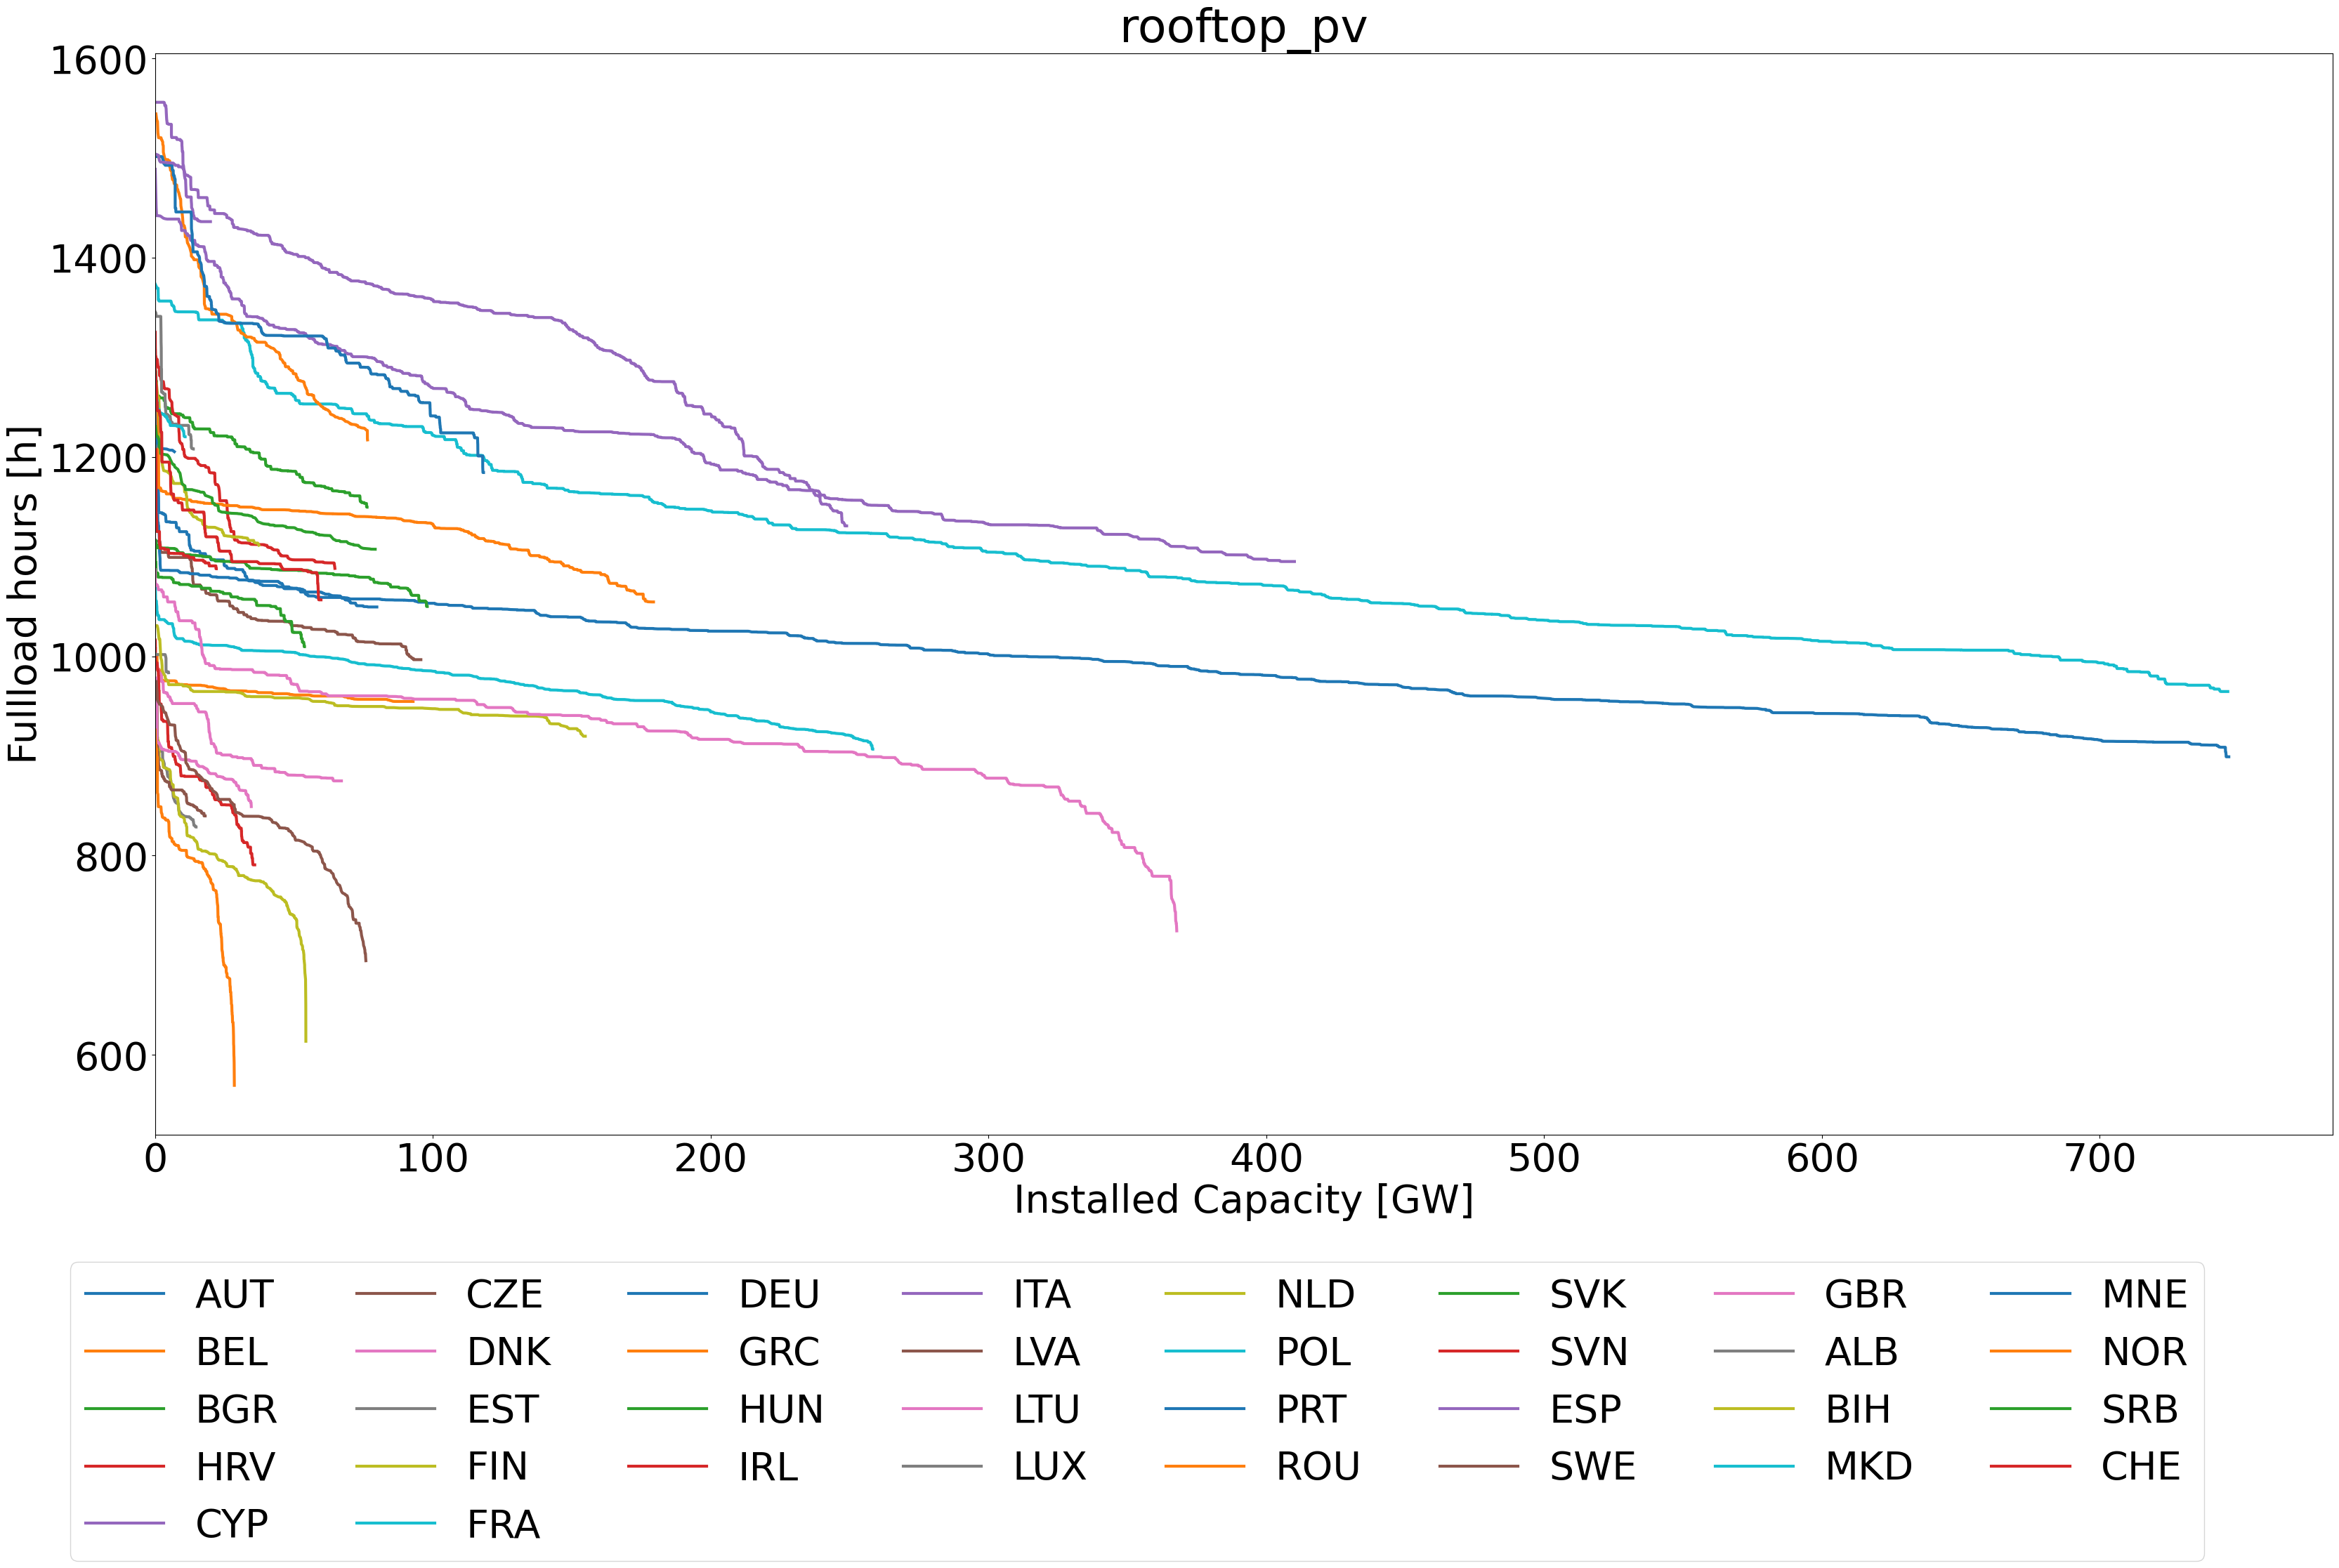

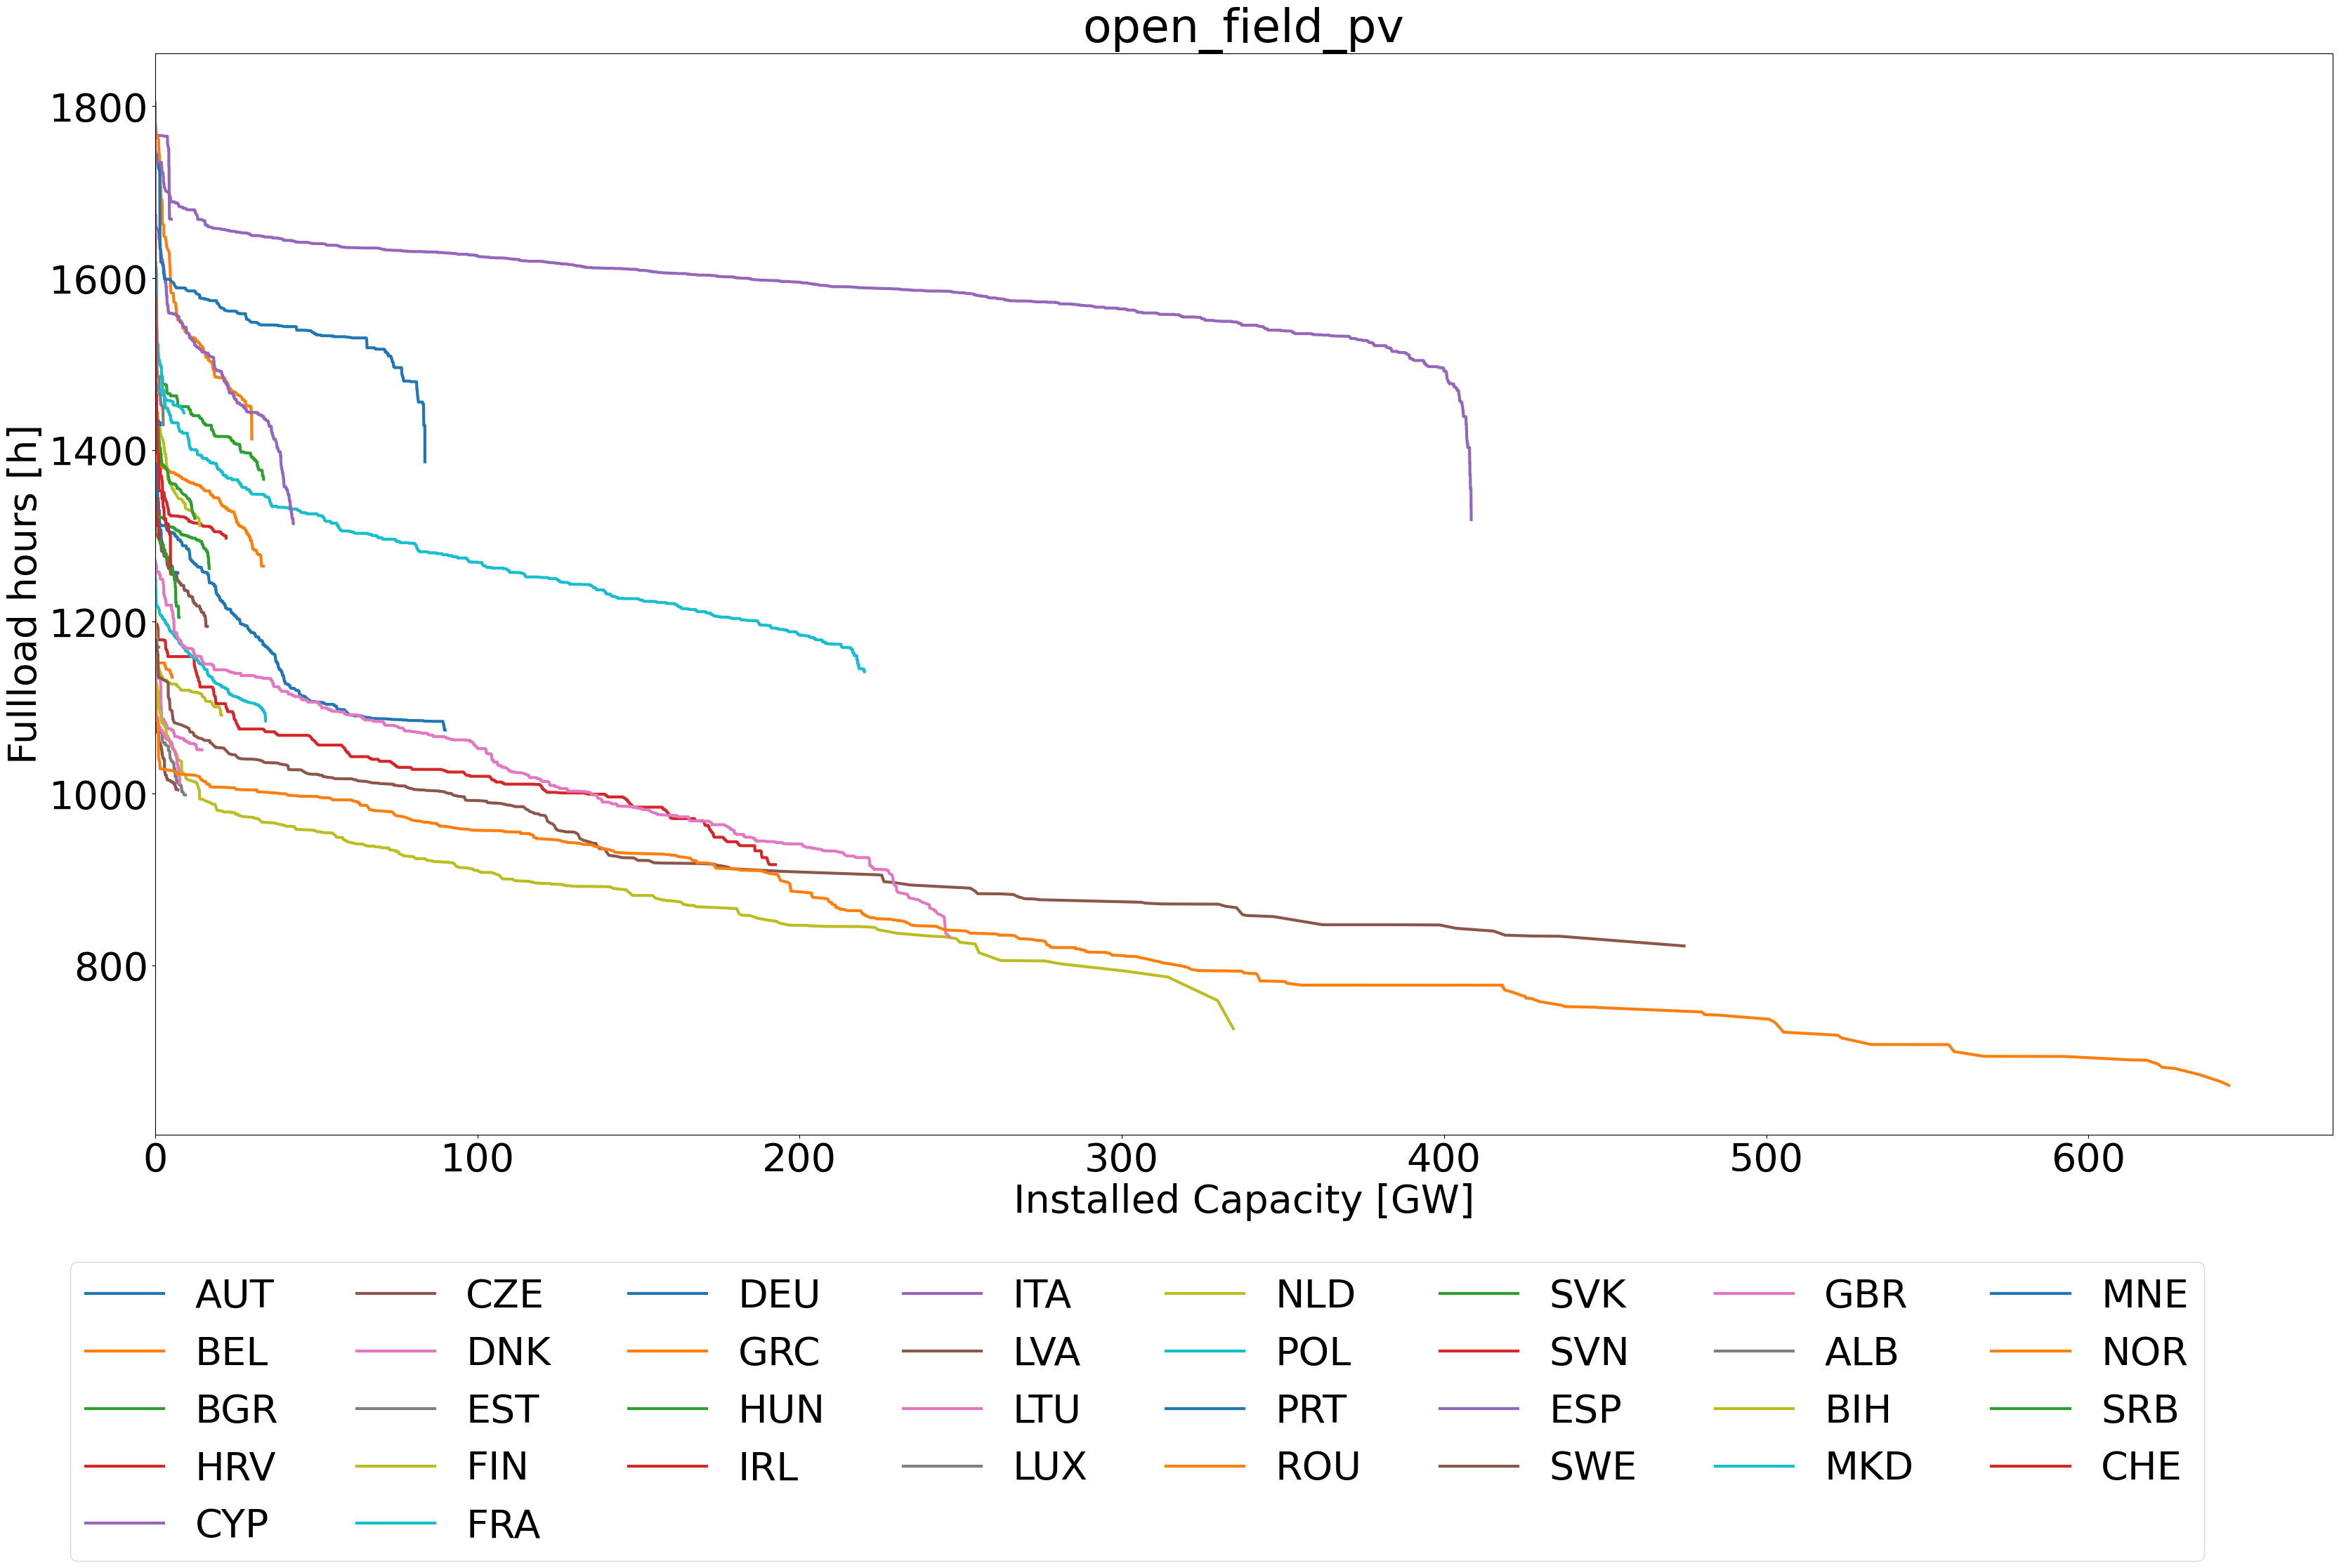

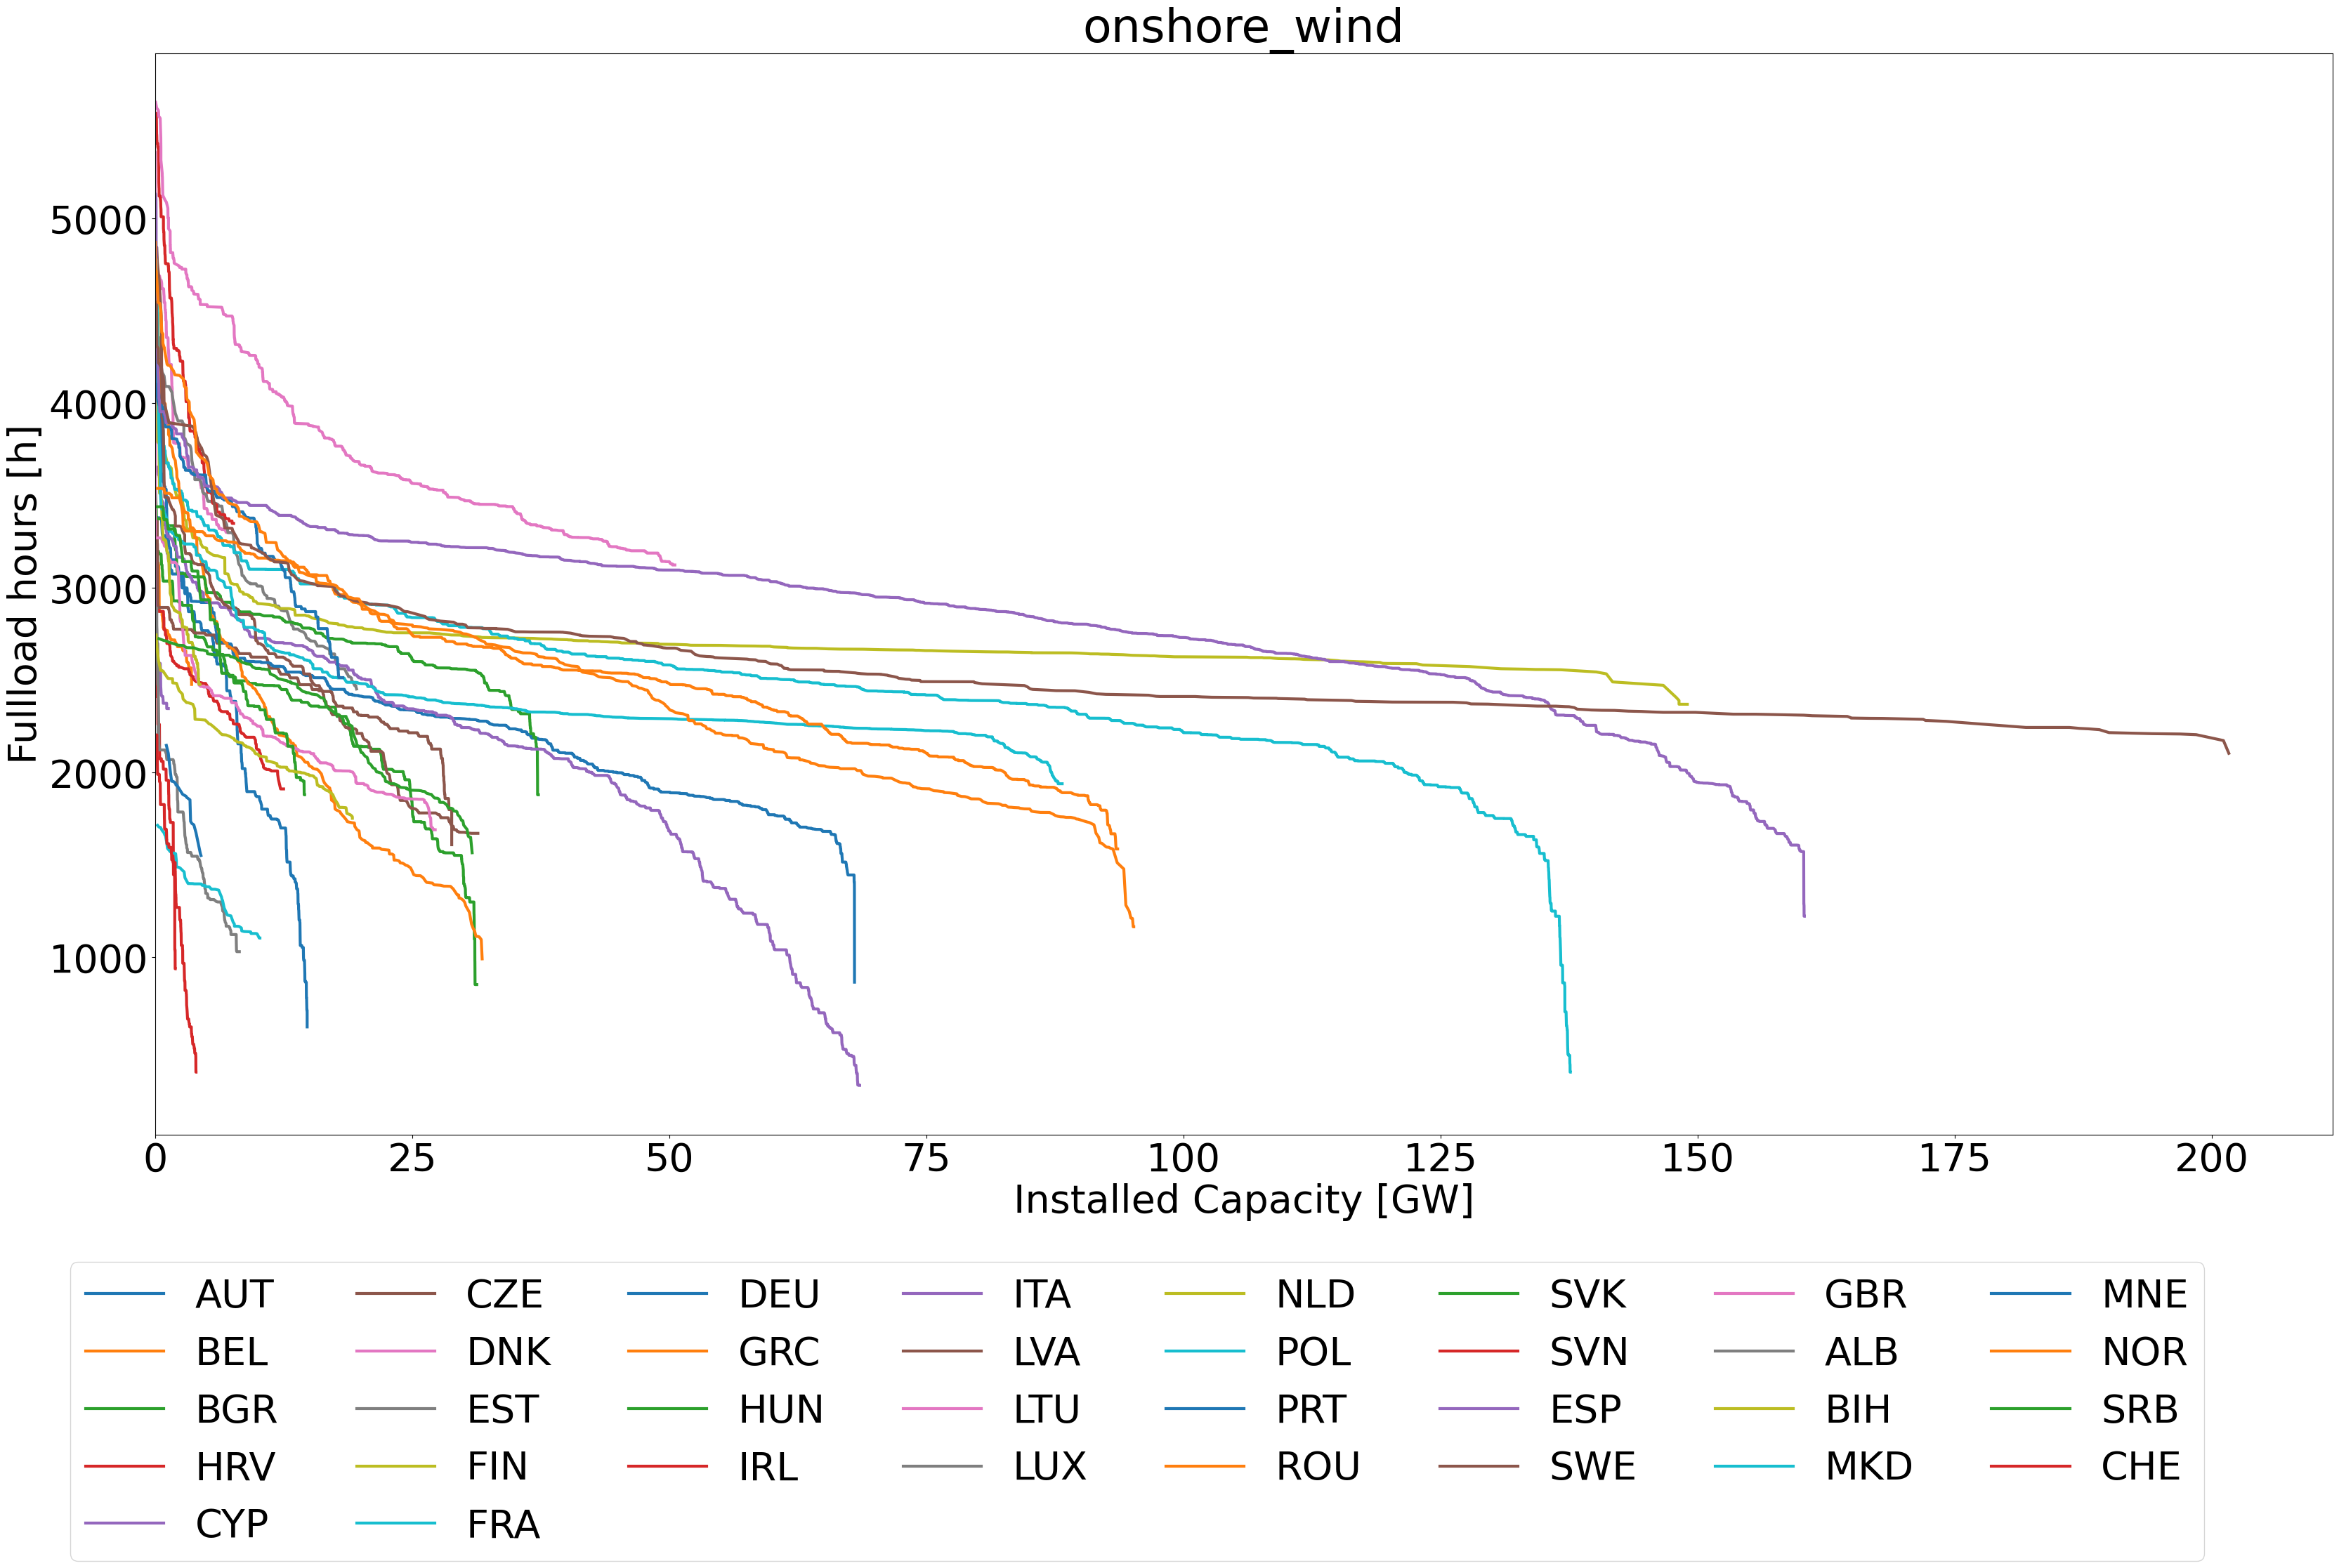

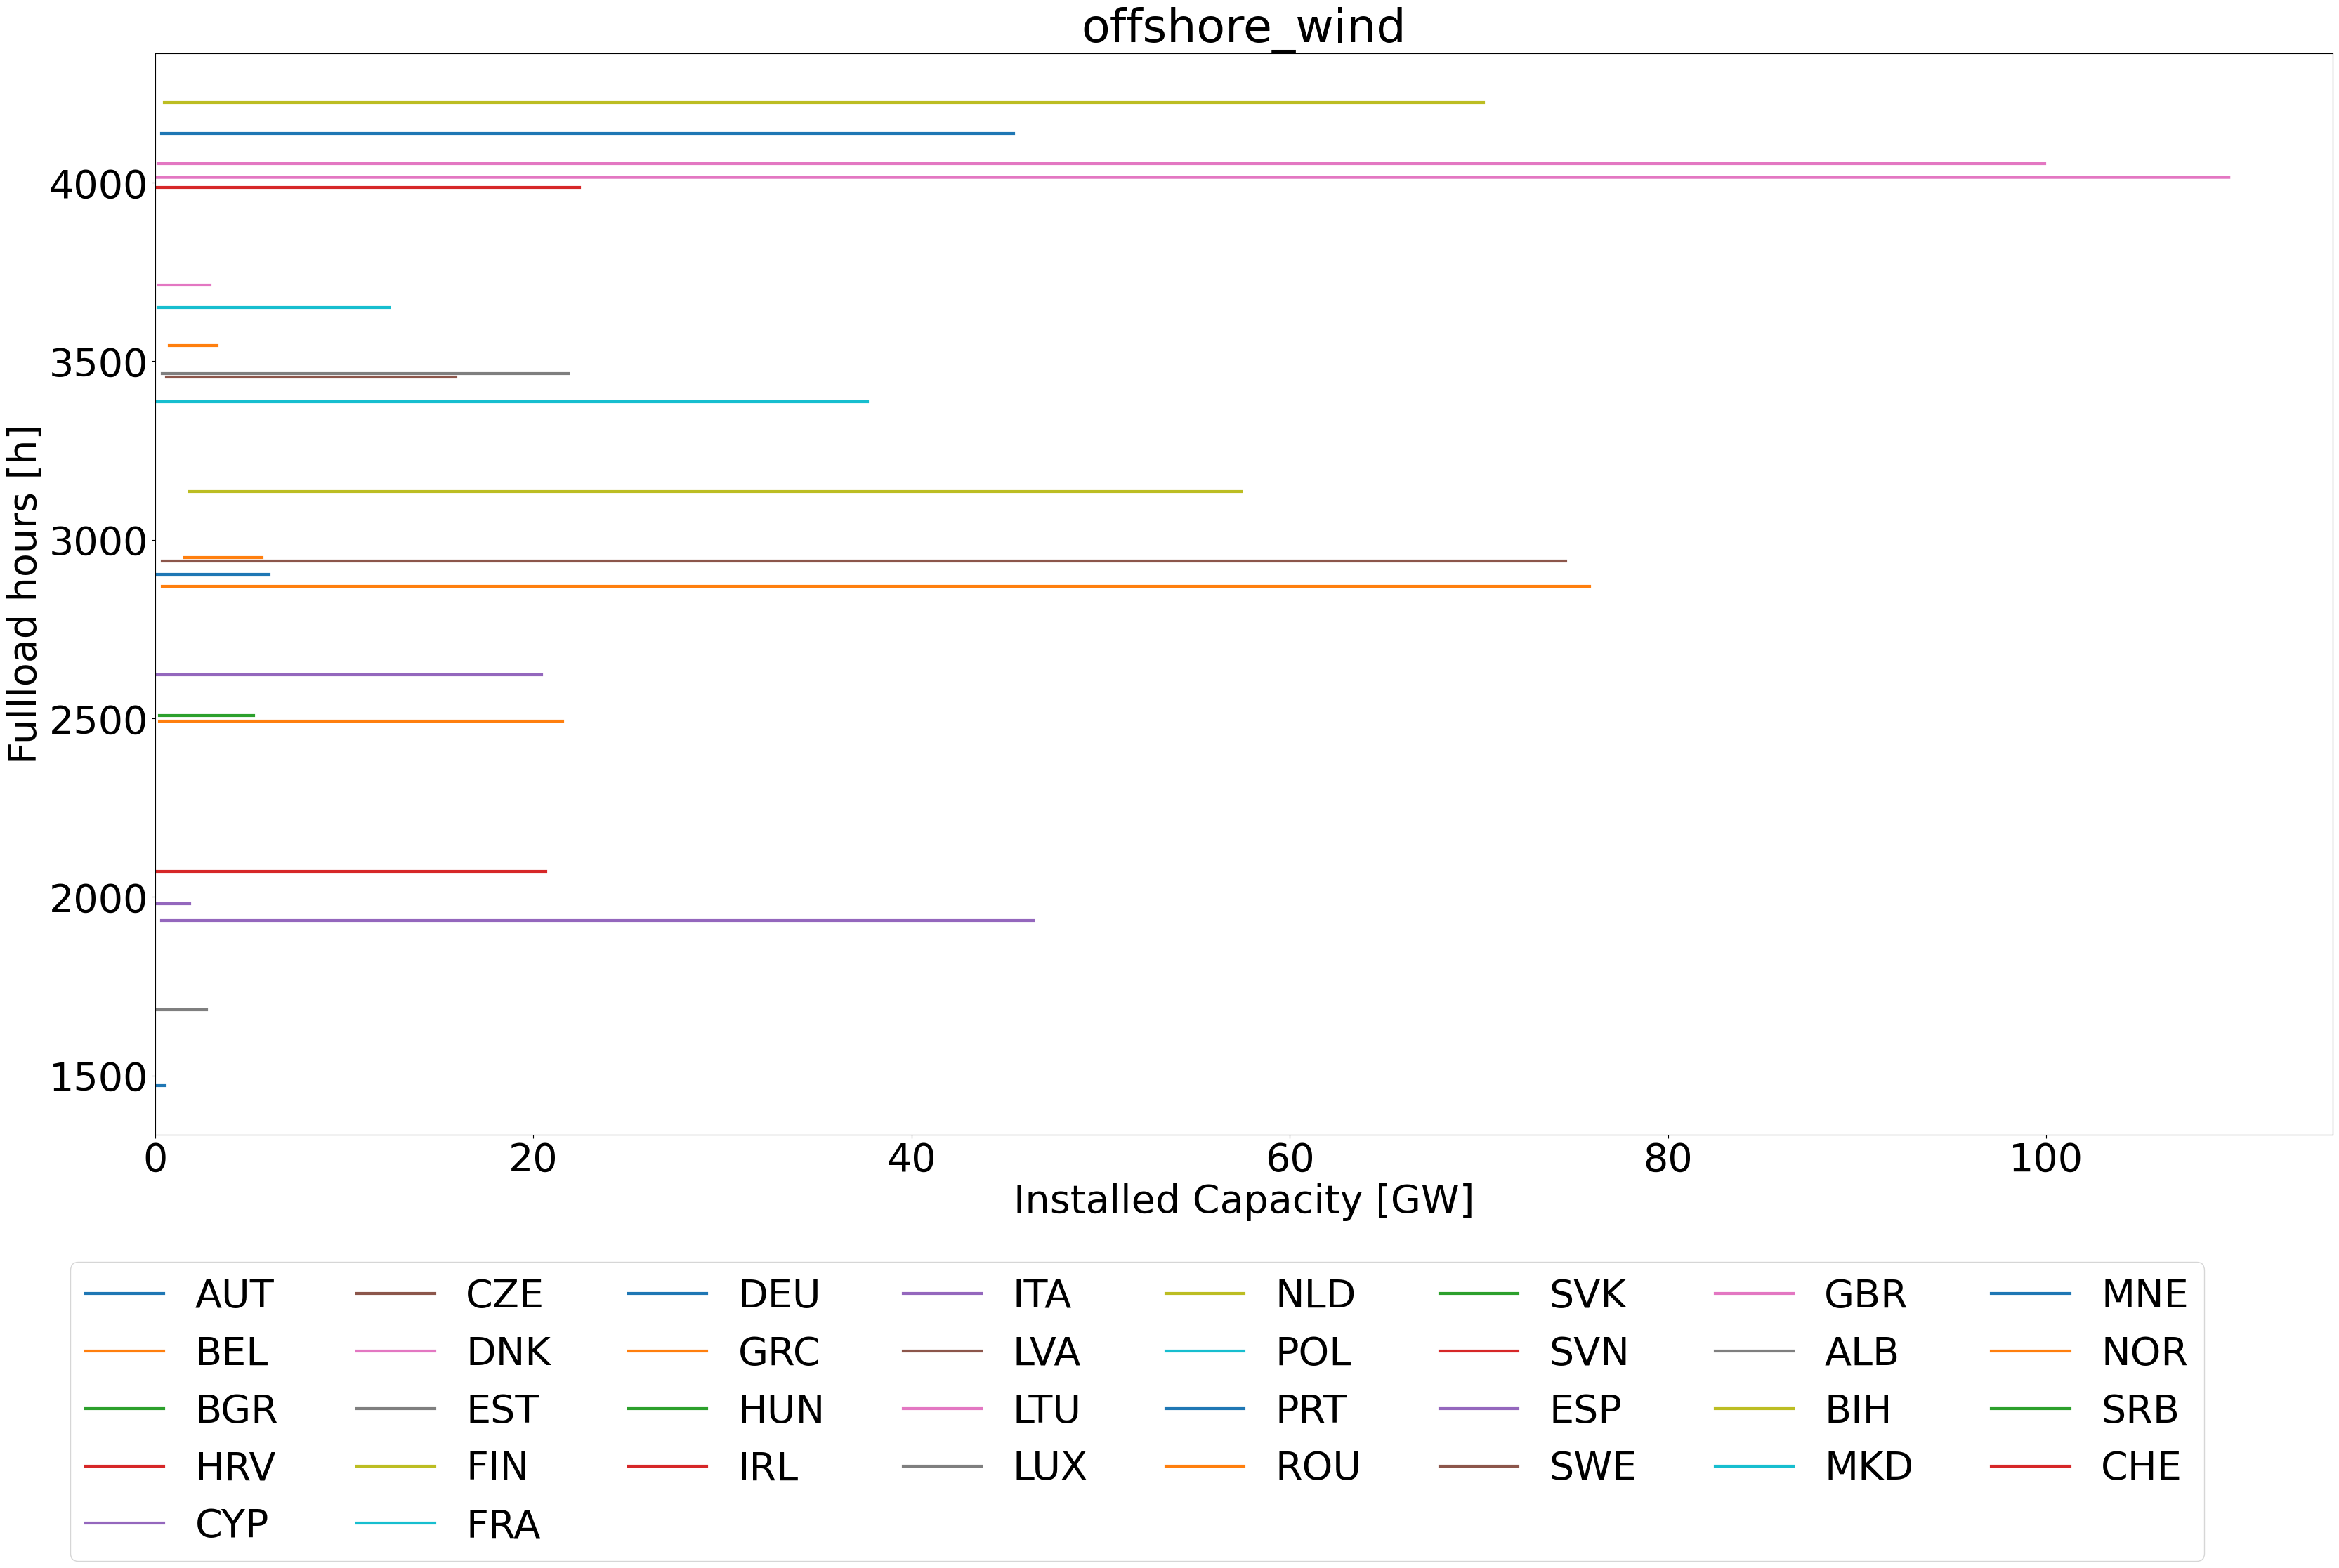

In [93]:
#tech = "rooftop_pv"
for tech in lst_tech:
    df_t = df_twh_mw[df_twh_mw.technology == tech].drop("technology", axis=1)
    fig, ax = plt.subplots()

    # for each country in the the list, plot sorted fulload hours by capacity
    for c in lst_countries:
        df_c = df_t[df_t.country_code == c].drop(["name", "id"], axis=1)
        df_c = df_c[df_c.mw > 0.0].sort_values("fullload_hours", ascending=False)
        df_c["mw_cum"] = df_c.mw.cumsum()/1000
        ax.plot(df_c.mw_cum, df_c.fullload_hours, label=c, lw=3)
    plt.legend(bbox_to_anchor=(0.95,-0.1), ncol=8)
    plt.xlabel("Installed Capacity [GW]")
    plt.ylabel("Fullload hours [h]")
    plt.xlim(0)
    plt.title(tech)
    #plt.savefig("../figures/fulload_hours_%s.pdf" % tech, bbox_inches="tight")

## Plot Cost Curve


In [ ]:
#tech = "rooftop_pv"
for tech in lst_tech:
    df_t = df_twh_mw[df_twh_mw.technology == tech].drop("technology", axis=1)
    fig, ax = plt.subplots()

    # for each country in the the list, plot sorted fulload hours by capacity
    for c in lst_countries:
        df_c = df_t[df_t.country_code == c].drop(["name", "id"], axis=1)
        df_c = df_c[df_c.mw > 0.0].sort_values("fullload_hours", ascending=False)
        df_c["mw_cum"] = df_c.mw.cumsum()/1000
        ax.plot(df_c.mw_cum, df_c.fullload_hours, label=c, lw=3)
    plt.legend(bbox_to_anchor=(0.95,-0.1), ncol=8)
    plt.xlabel("Installed Capacity [GW]")
    plt.ylabel("Fullload hours [h]")
    plt.xlim(0)
    plt.title(tech)

C:\Users\jonas\AppData\Local\Temp\ipykernel_4544\886382696.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_t = df_all[df_twh_mw.technology == tech].drop("technology", axis=1)
C:\Users\jonas\AppData\Local\Temp\ipykernel_4544\886382696.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_t = df_all[df_twh_mw.technology == tech].drop("technology", axis=1)
C:\Users\jonas\AppData\Local\Temp\ipykernel_4544\886382696.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_t = df_all[df_twh_mw.technology == tech].drop("technology", axis=1)
C:\Users\jonas\AppData\Local\Temp\ipykernel_4544\886382696.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_t = df_all[df_twh_mw.technology == tech].drop("technology", axis=1)


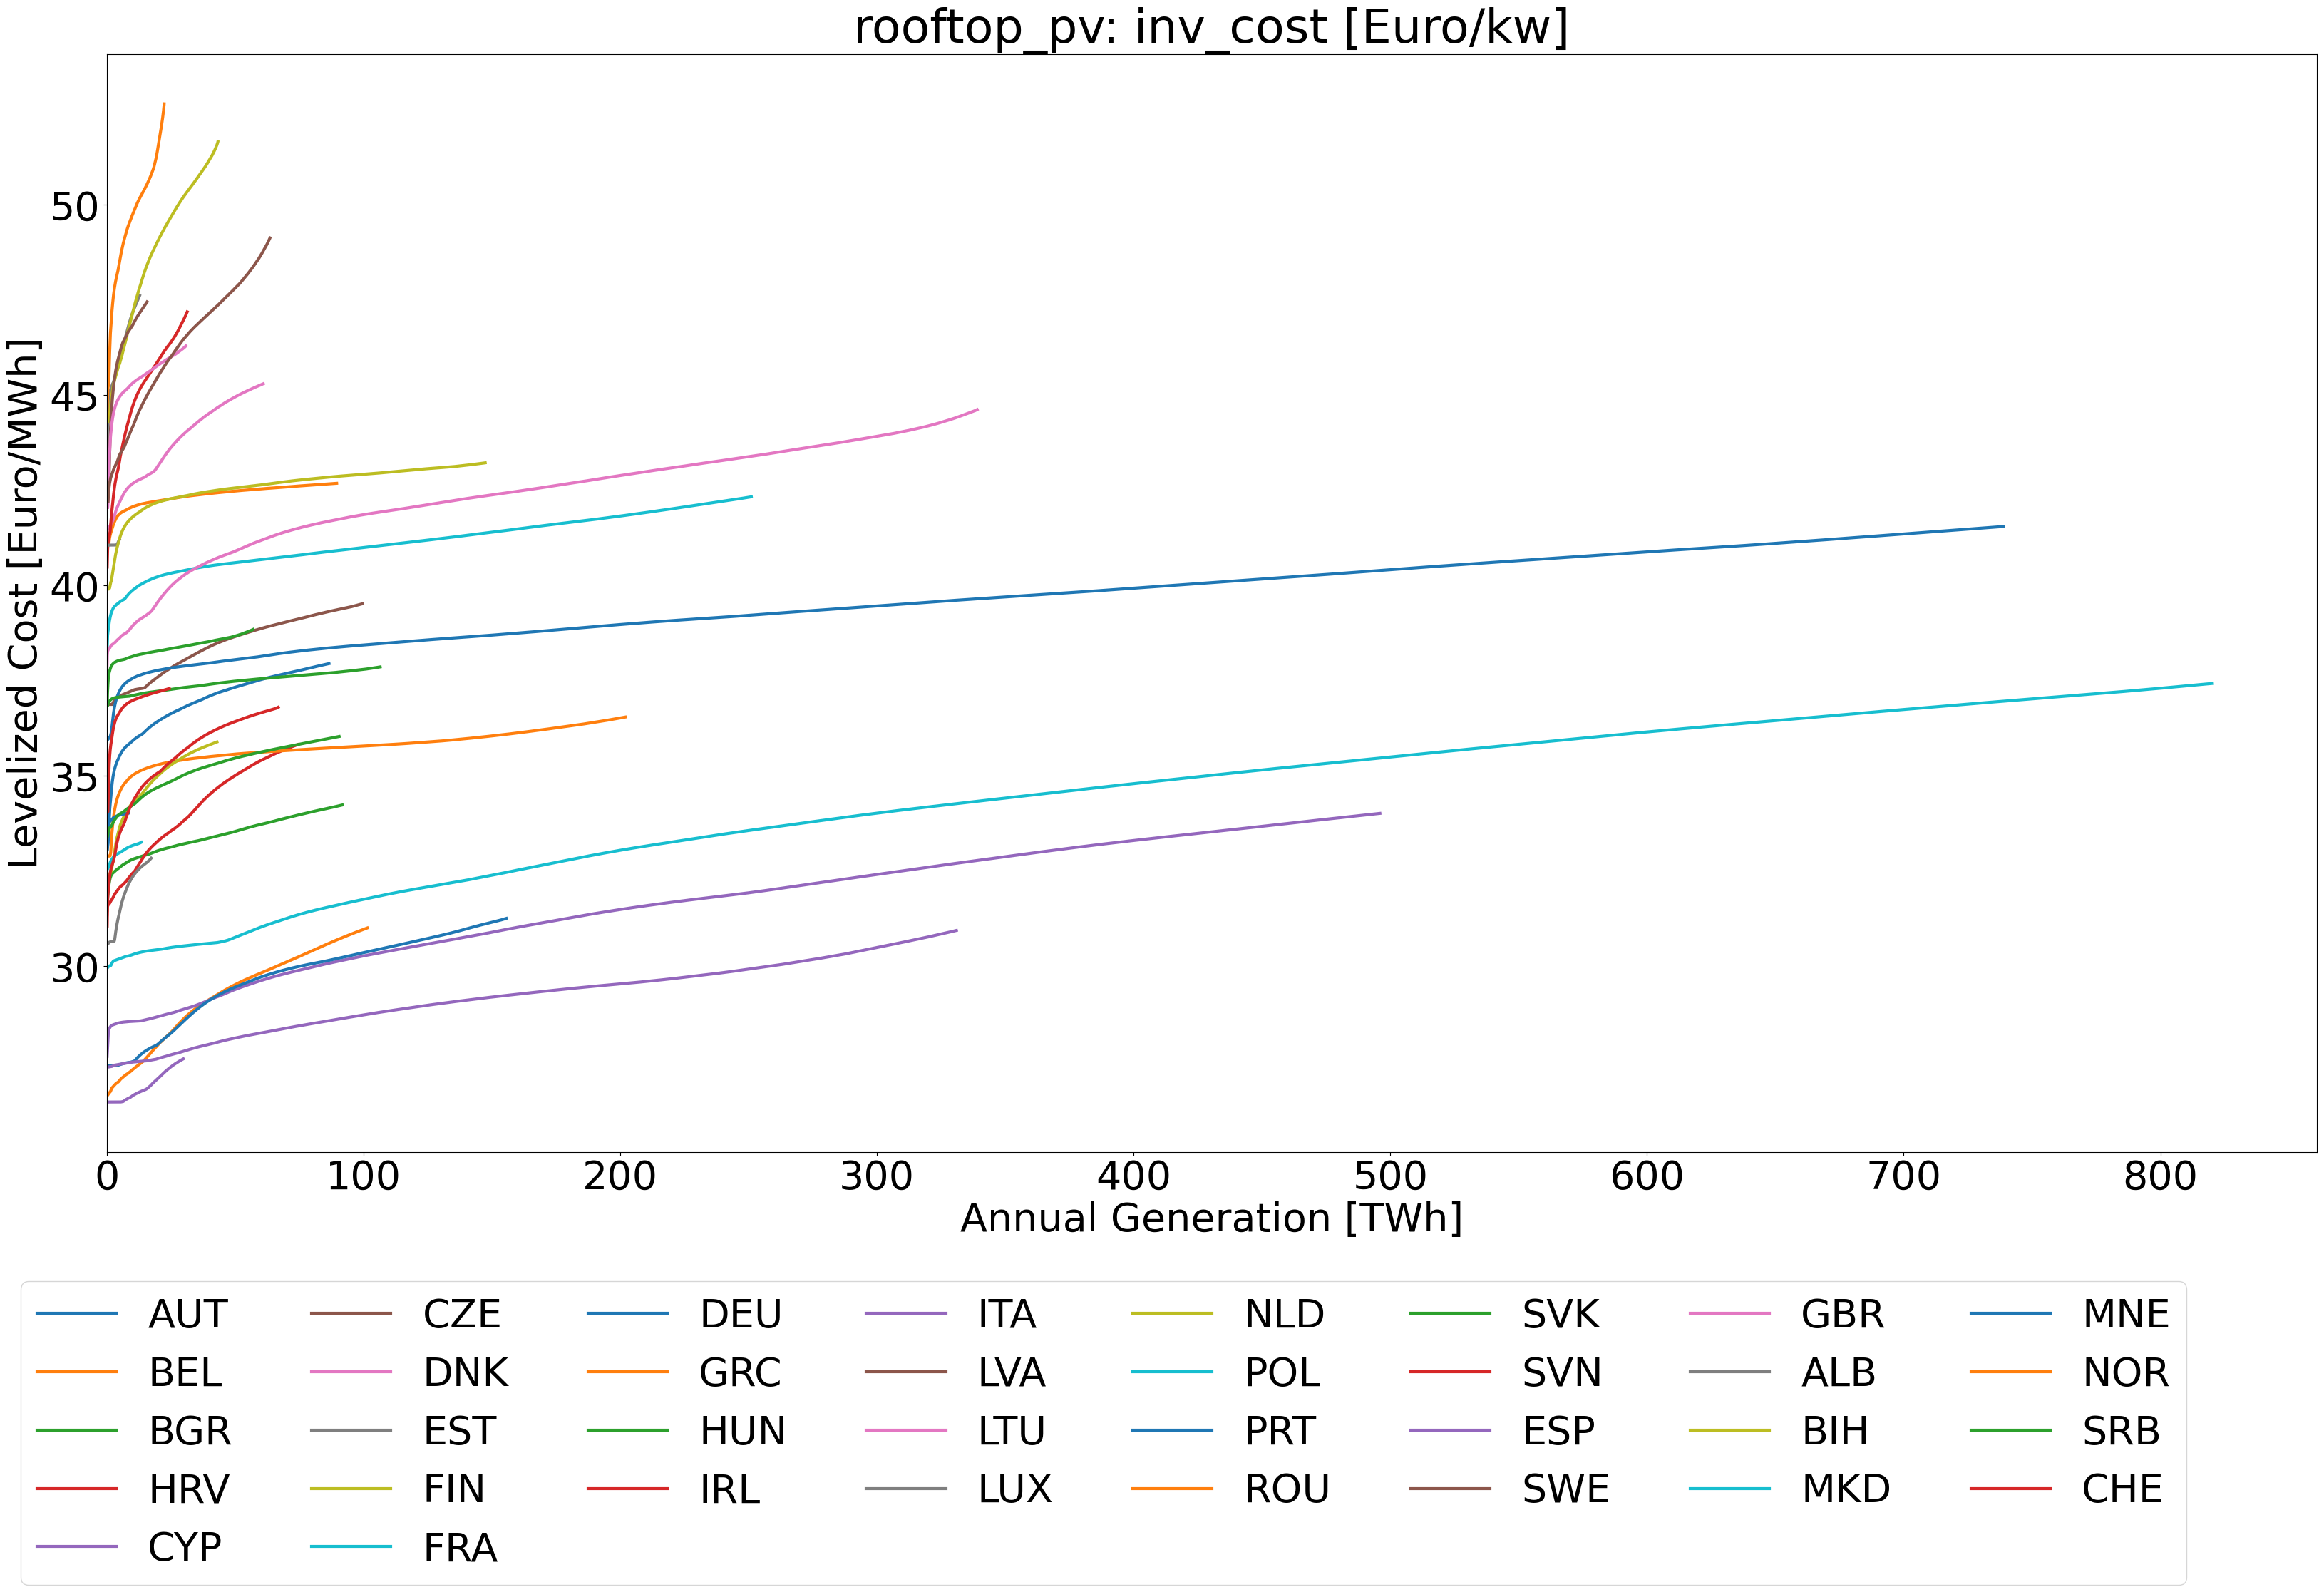

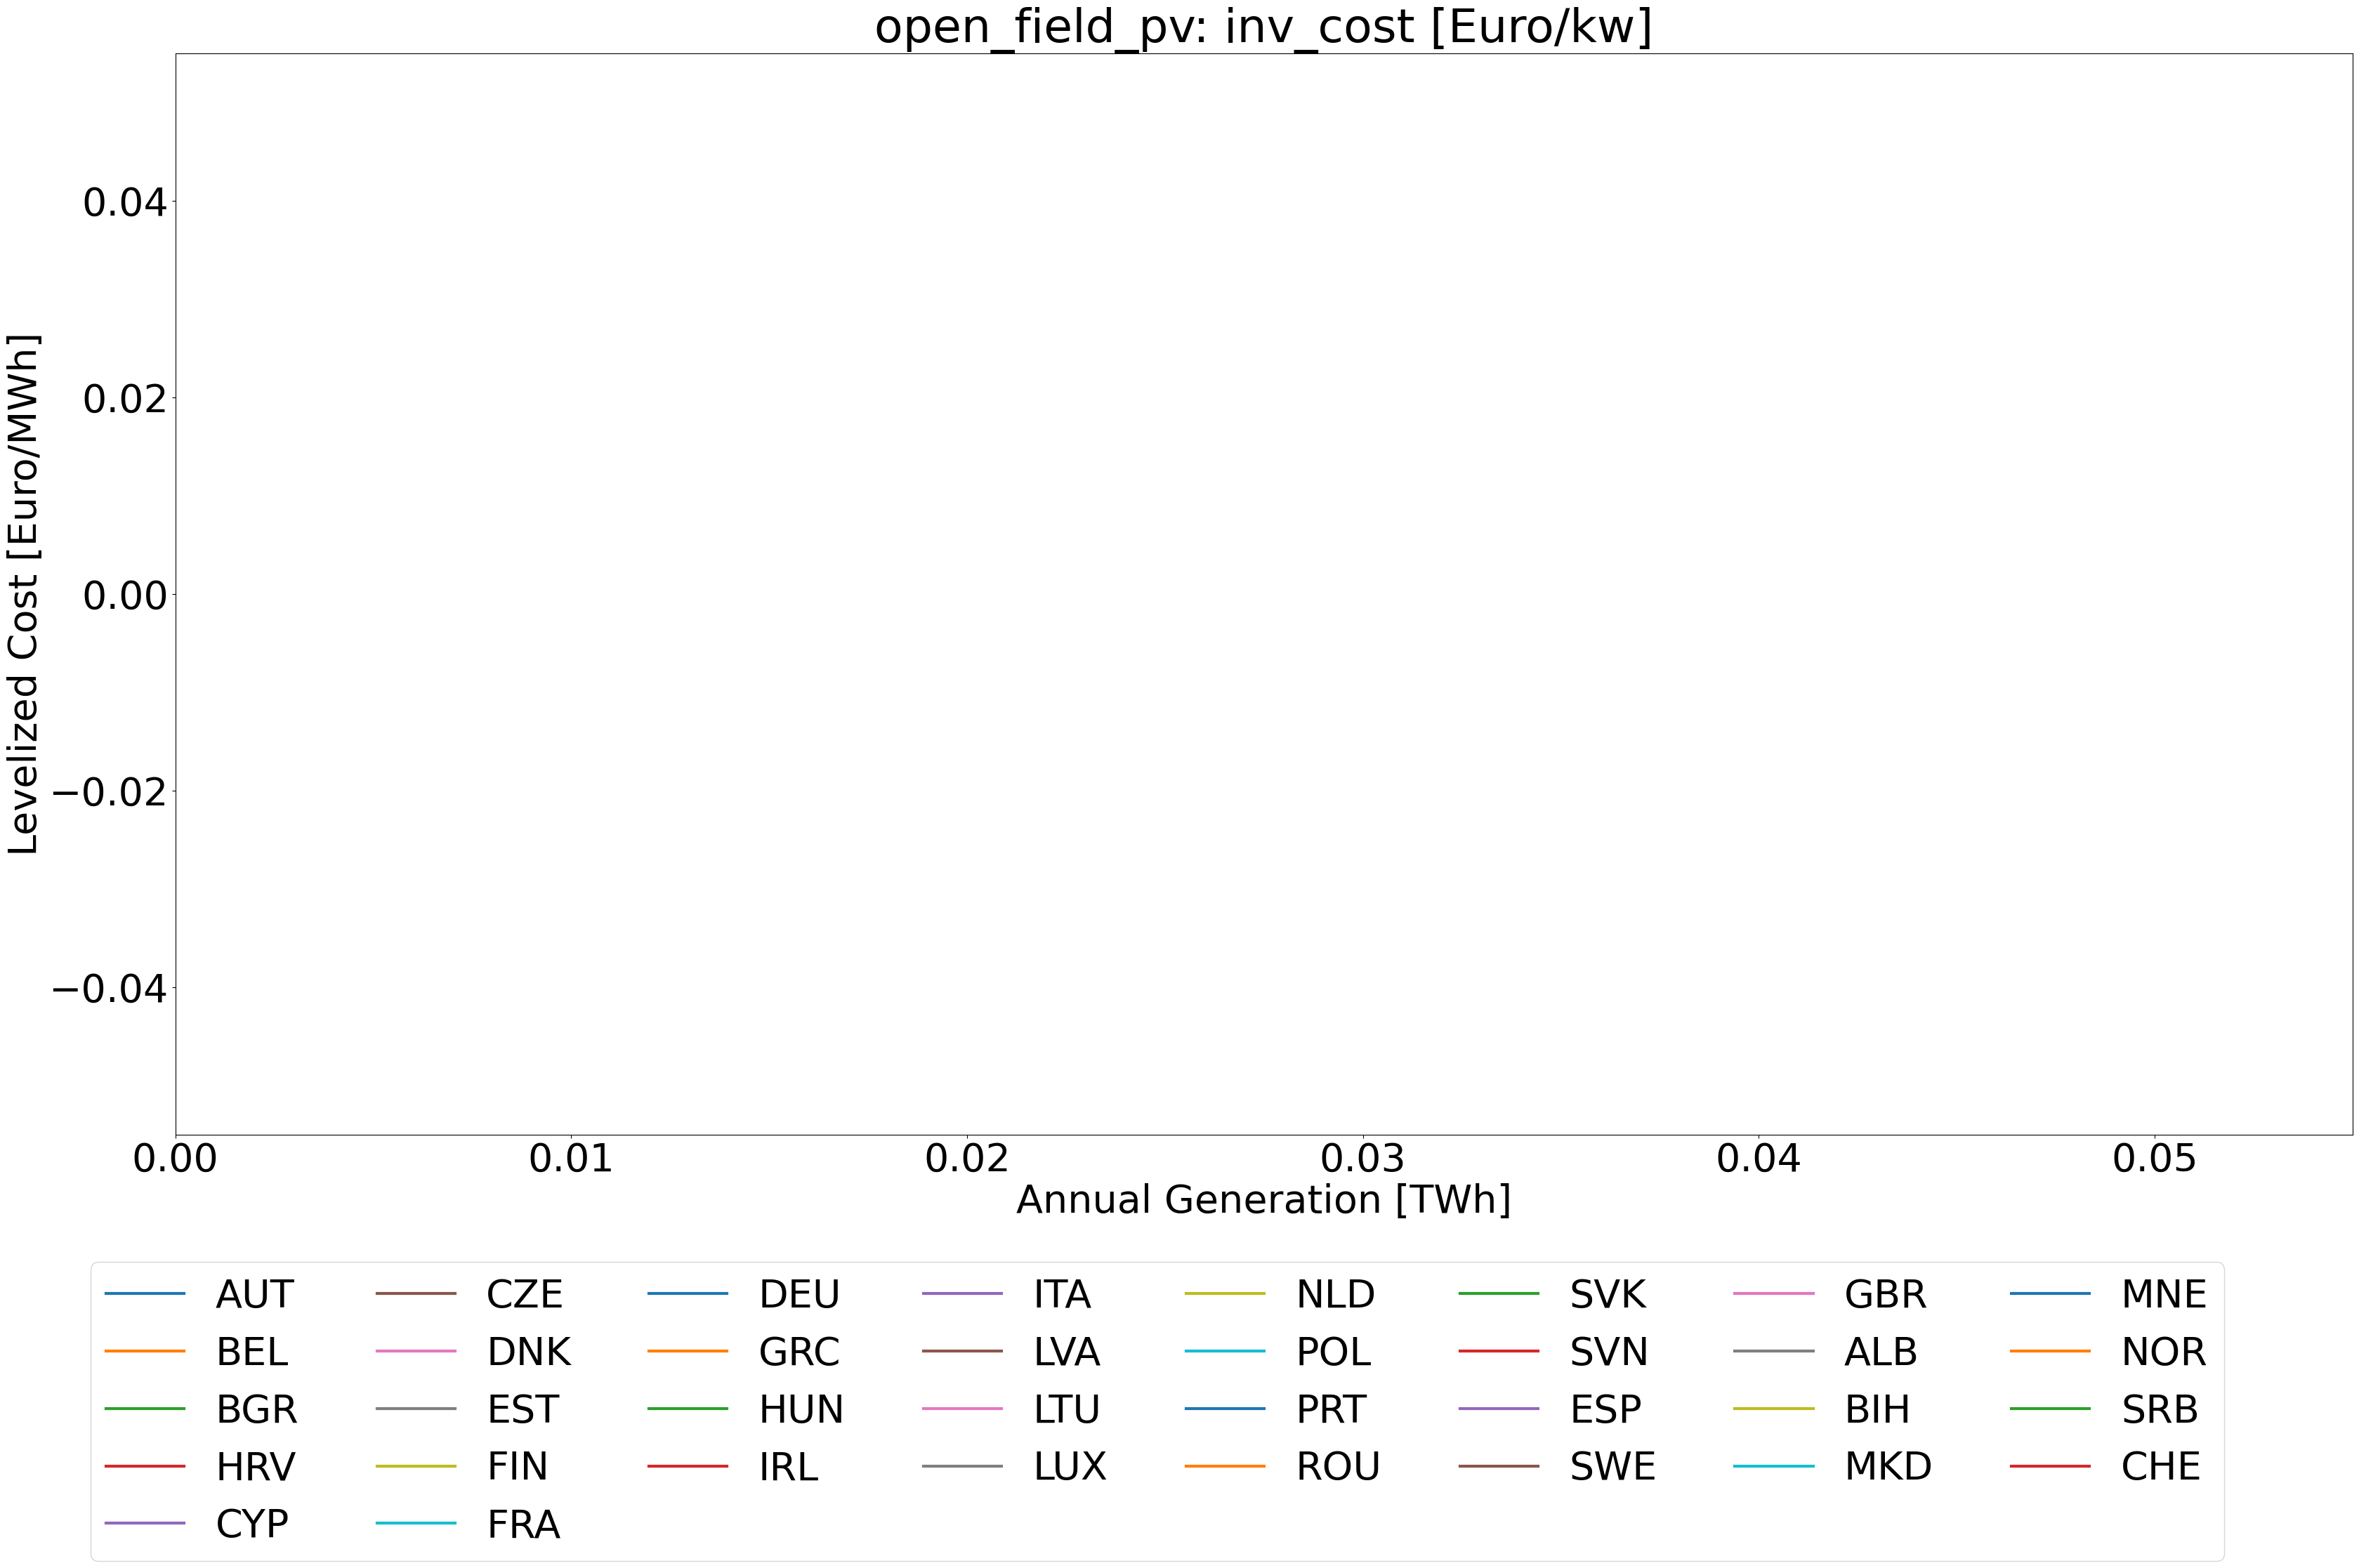

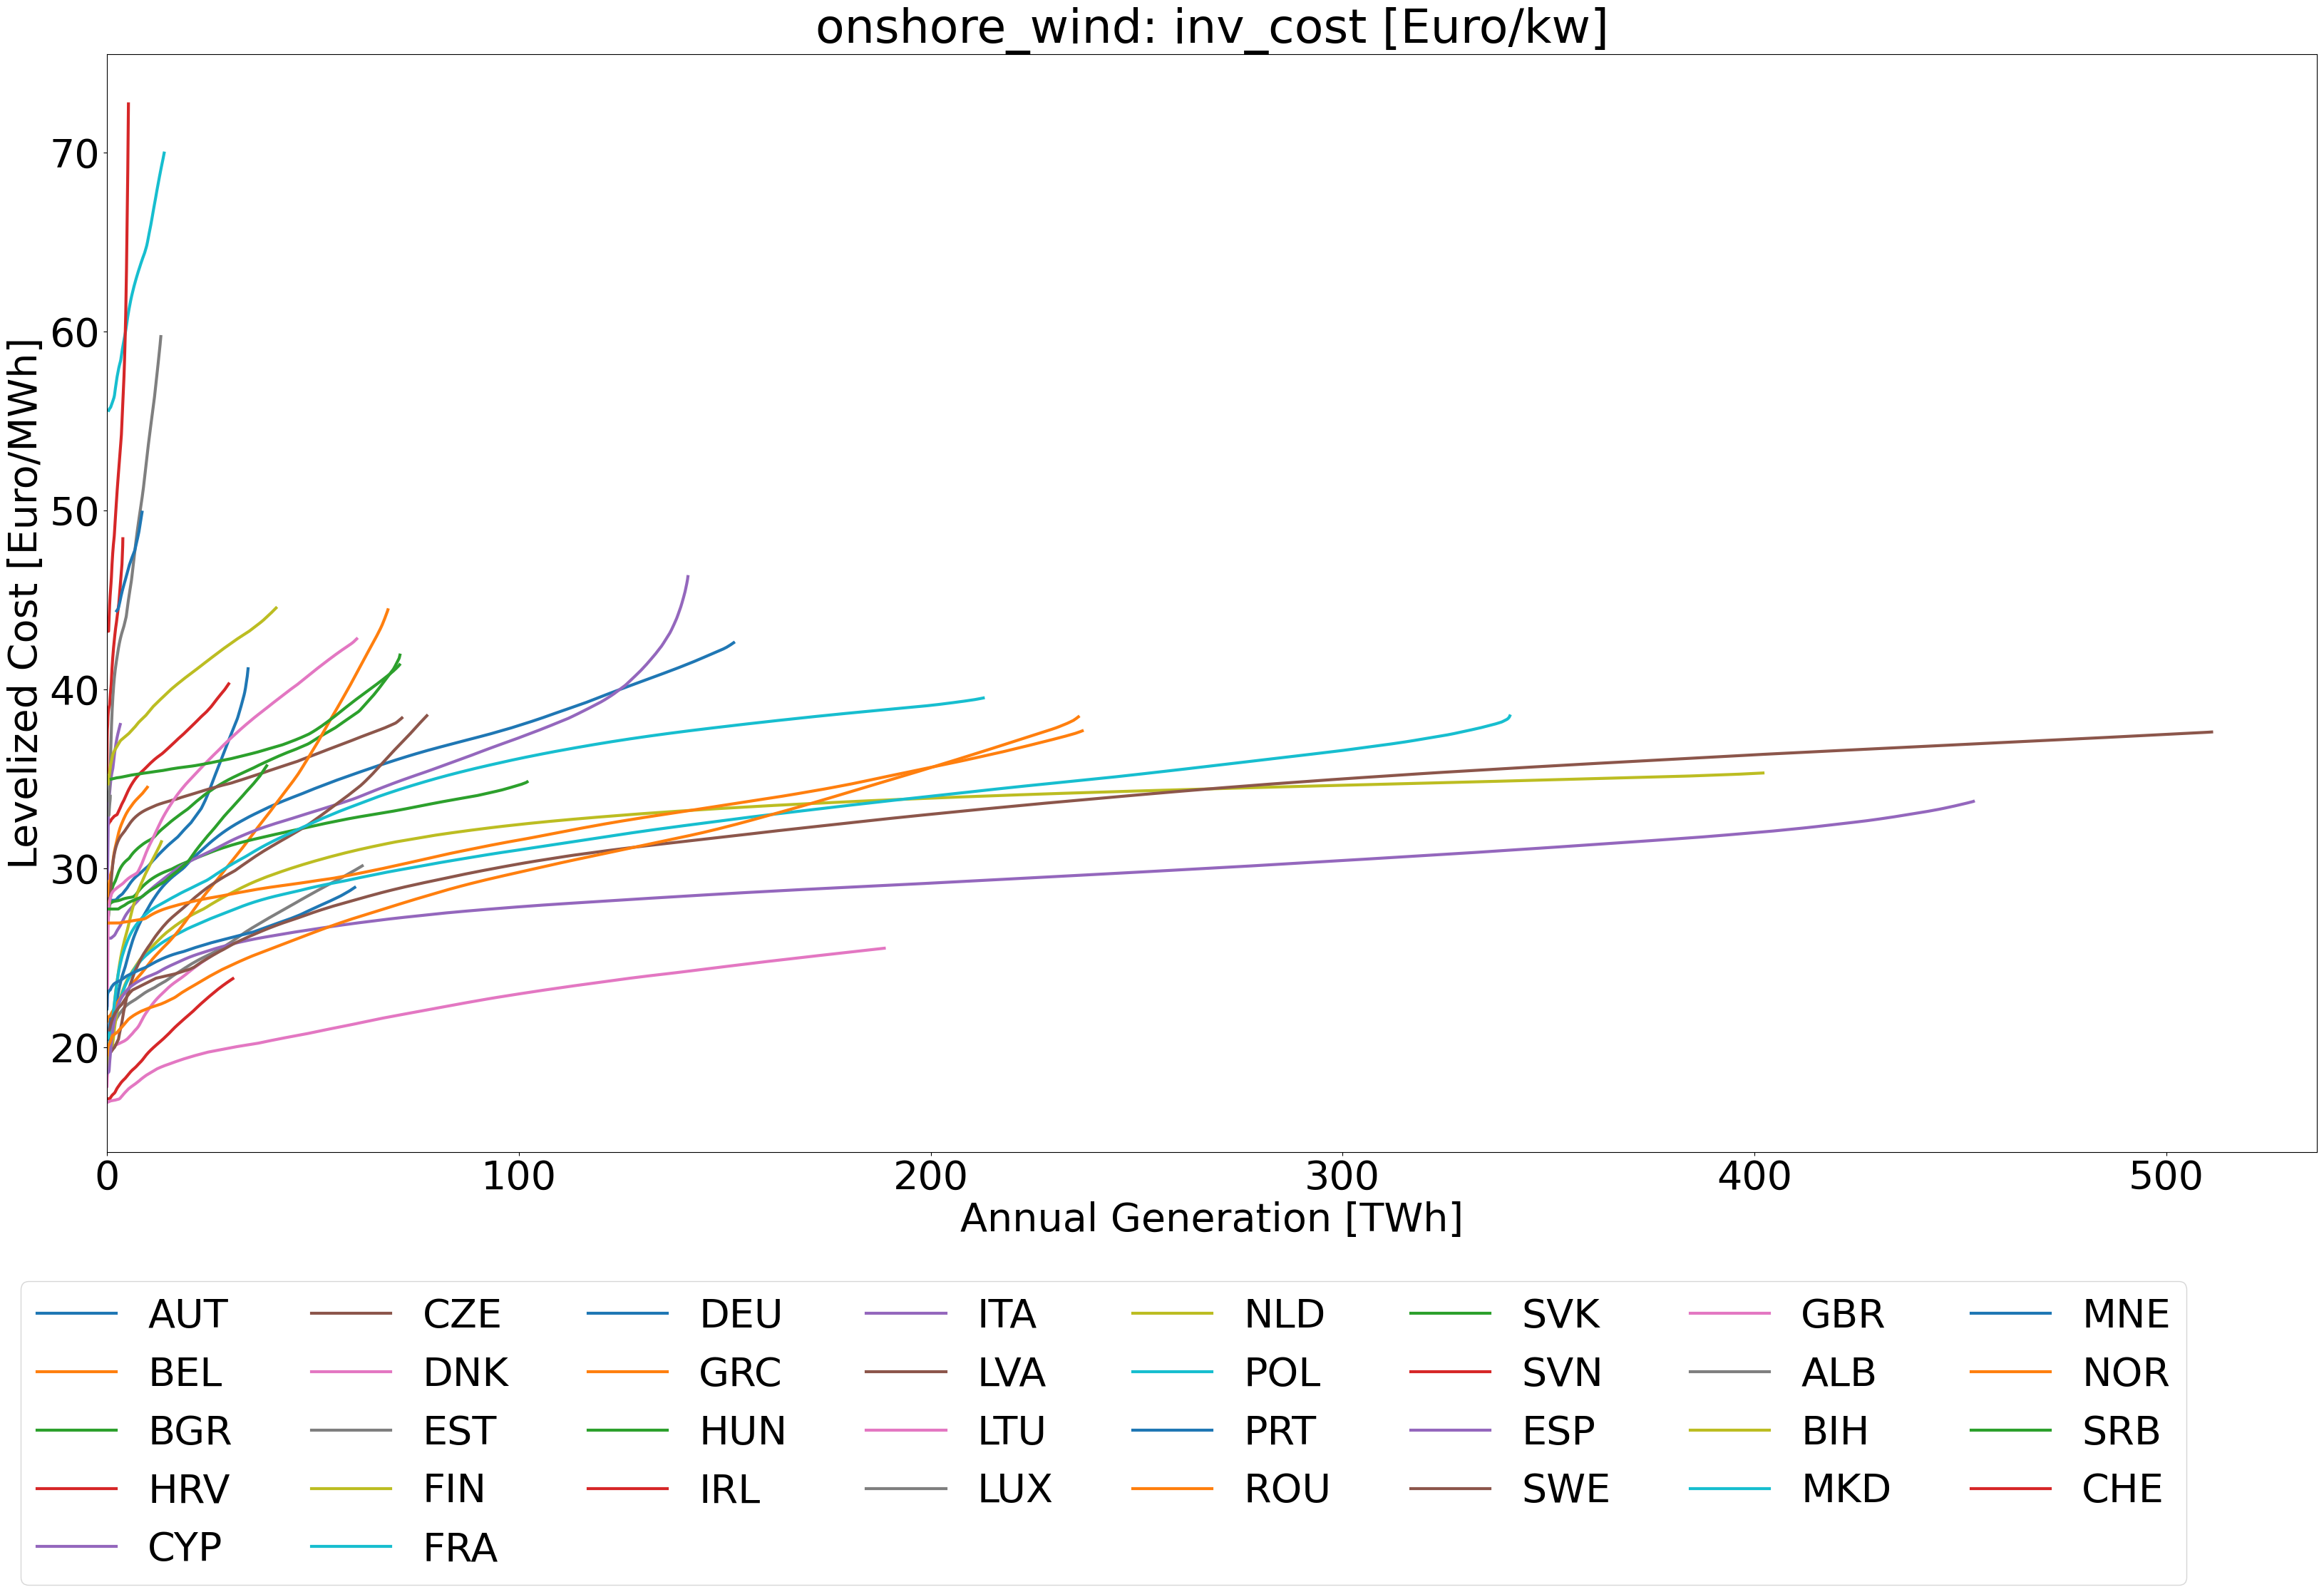

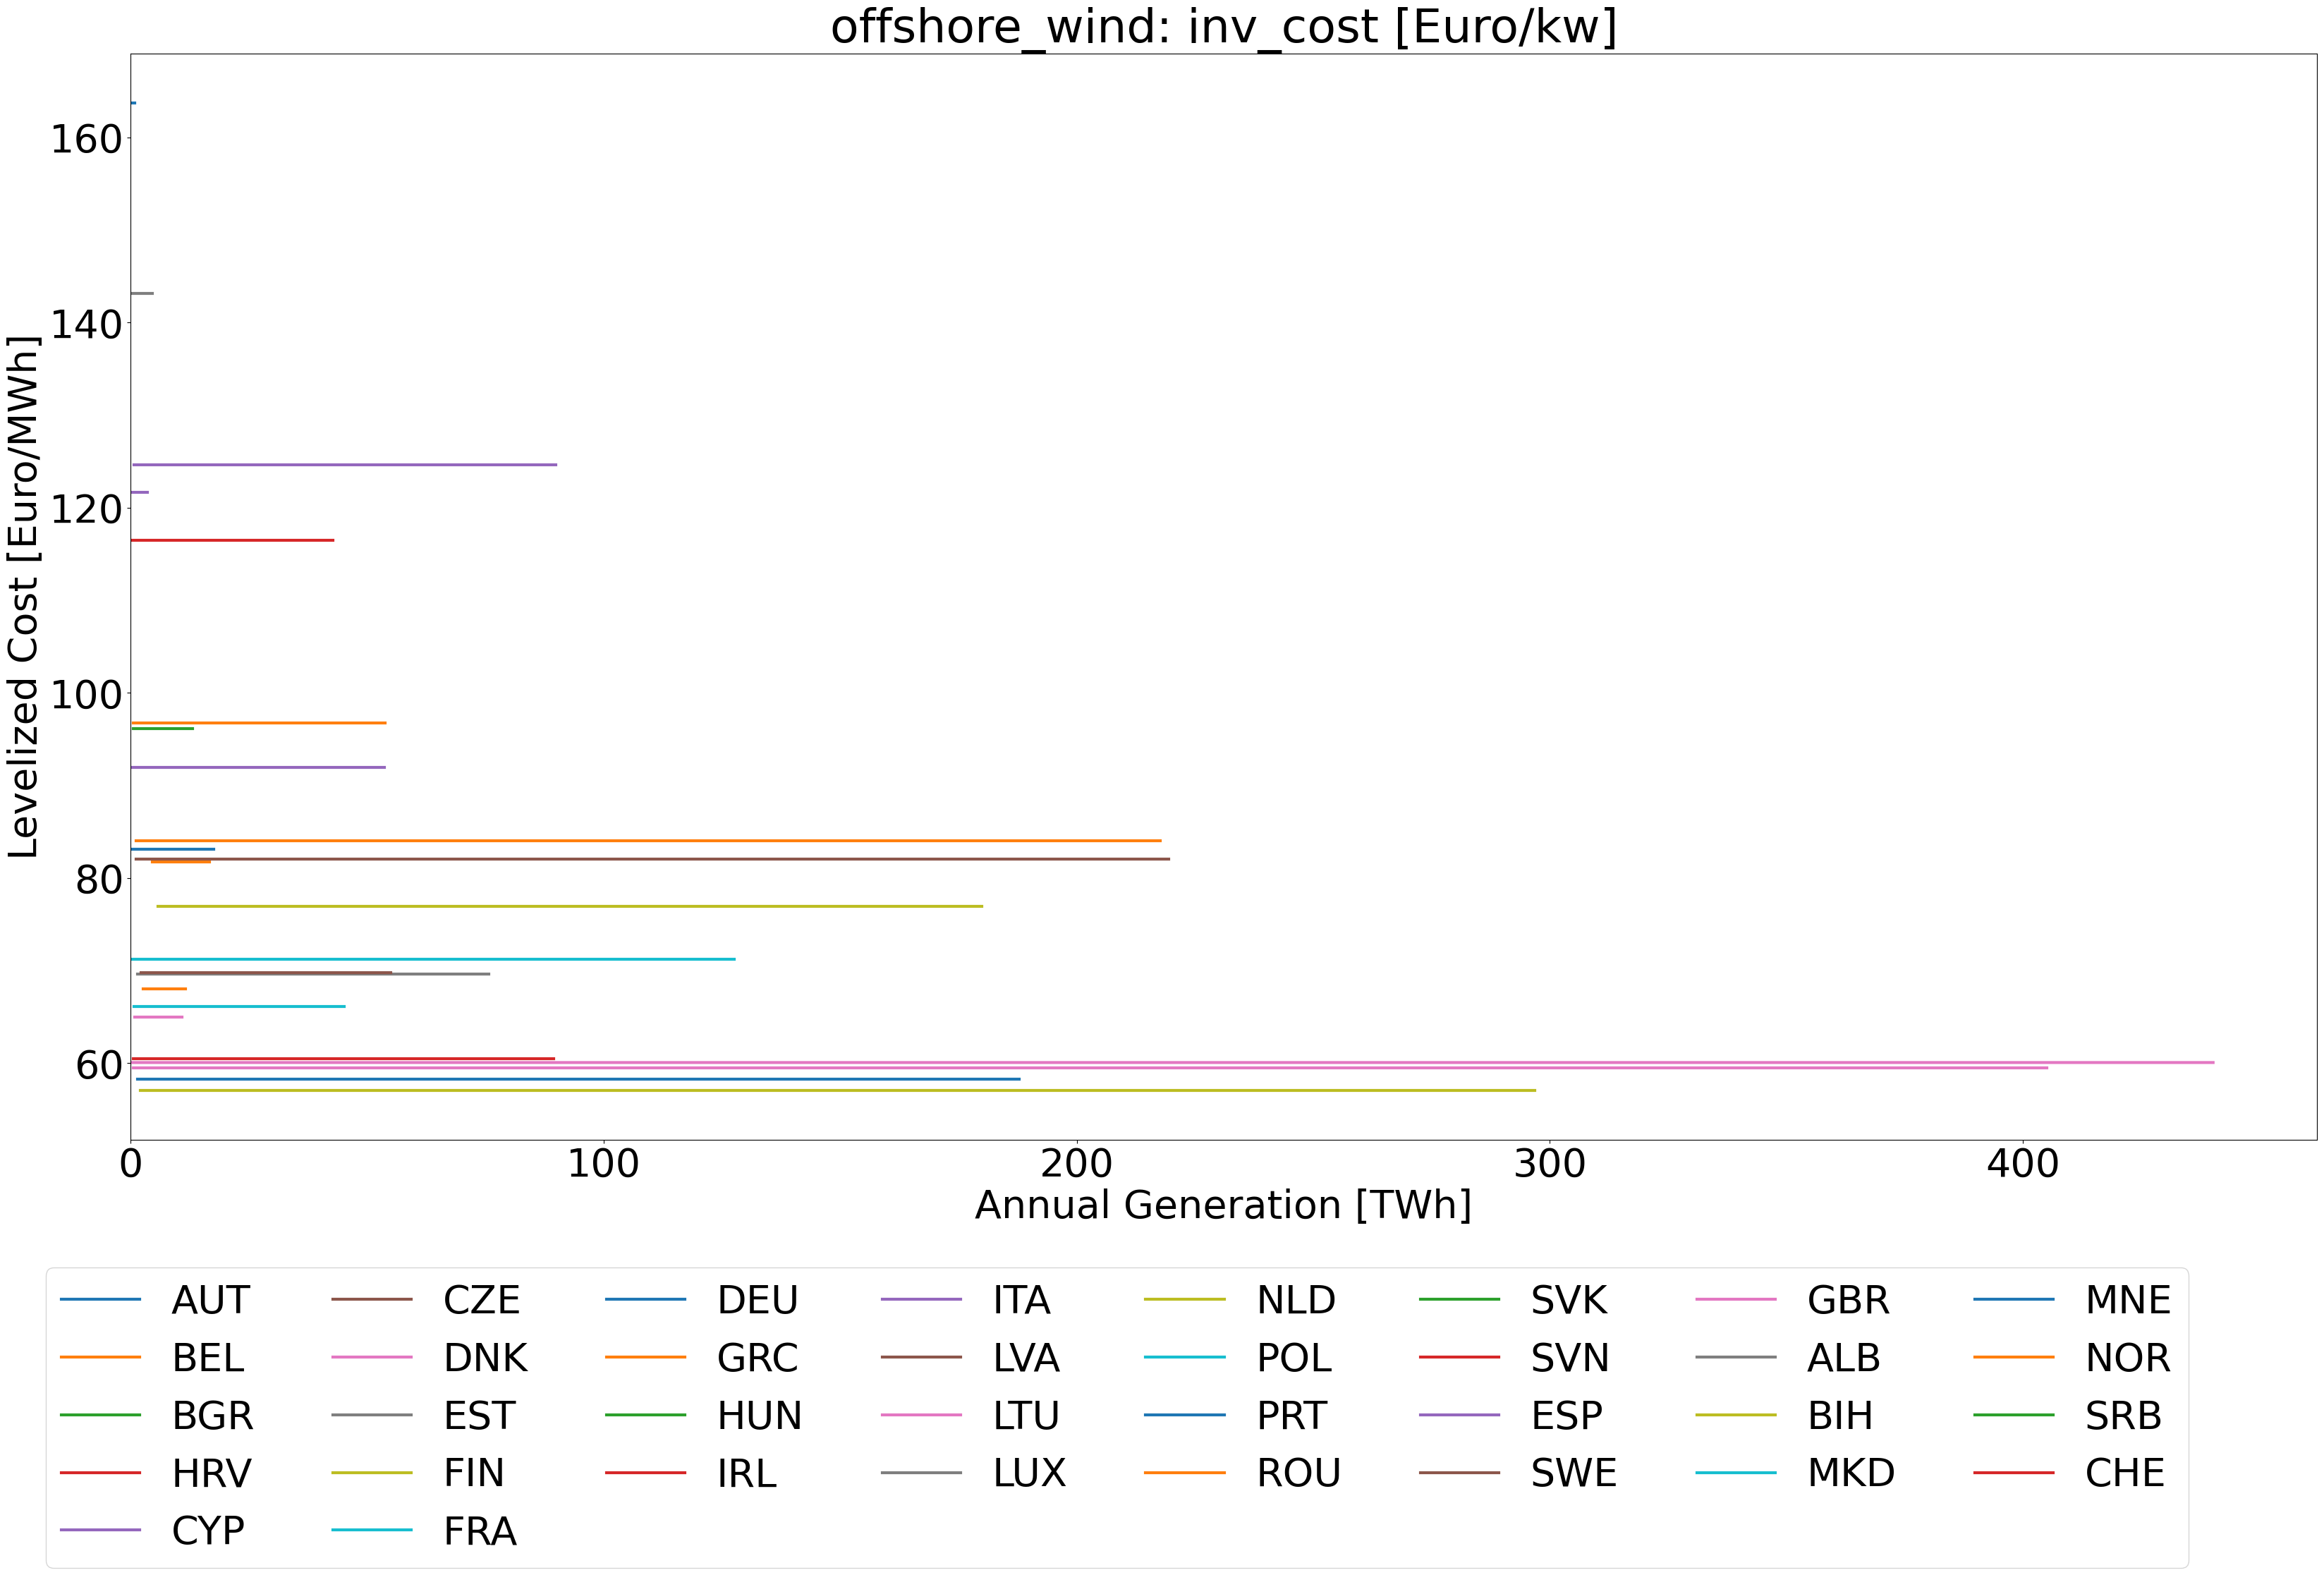

In [97]:
for tech in lst_tech:
    df_t = df_all[df_twh_mw.technology == tech].drop("technology", axis=1)
    fig, ax = plt.subplots()
    # for each country in the the list, plot sorted fulload hours by capacity
    for c in lst_countries:
        df_c = df_t[df_t.country_code == c].drop(["name", "id"], axis=1)
        df_c = df_c[df_c.mw > 0.0].sort_values("fullload_hours", ascending=False)
        df_c["mw_cum"] = df_c.mw.cumsum()
        df_c["twh_cum"] = df_c.twh.cumsum()
        df_c["annual_cost"] = df_c["mw_cum"]*df_c["euro_mw"]/1000000
        df_c["levelized_cost"] = df_c["annual_cost"]/df_c["twh_cum"]
        ax.plot(df_c.twh_cum, df_c.levelized_cost, label=c, lw=3)
    plt.legend(bbox_to_anchor=(0.95,-0.1), ncol=8)
    plt.xlabel("Annual Generation [TWh]")
    plt.ylabel("Levelized Cost [Euro/MWh]")
    plt.xlim(0)
    plt.title(tech + ": %s" % s)
    #plt.savefig("../figures/levelized_cost_%s.pdf" % tech, bbox_inches="tight")

## Fit cost curves

We fit a cost curve providing total annual cost depending on the MWh produced in a year.

In [102]:
def fit_cost_curves(df, technology, country, plot_fit=True, zero_intercept=True):
    """Fitting of cost curve: Annual cost as function of annual generation. A quadratic curve is used and the intercept is set 
       to zero
    :param df: <pd.DataFrame> with potential data
    :param technology: <string> technology to fit
    :param country: <string> country to fit
    :param plot_fit: <boolean> true to provide plot of fitted and original curves as well as marginal cost
    :param zero_intercept: <boolean> true to set intercept to zero"""
    df_ = df[(df_all.technology == technology) & (df_all.country_code == country)
               & (df_all.fullload_hours.notnull())].sort_values("fullload_hours", ascending=False)
    df_["mw_cum"] = df_.mw.cumsum()
    df_["annual_cost"] =  df_["mw_cum"]*df_["euro_mw" ]
    df_["twh_cum"] = df_.twh.cumsum()

    # get potentials
    pot_twh = df_["twh_cum"].max()
    pot_mw = df_["mw_cum"].max()
    
    # check that potential is not zero
    if (pot_mw == 0) or (pd.isnull(pot_mw)):
        res = {"country": country, "technology": technology, "a": 0, "b": 0, "c": 0, 
                  "potential_twh": 0, "potential_mw": 0}        
        return res 
    
    # get x and y values for fitting
    x = df_.twh_cum.values*1000000
    y = df_.annual_cost.values
    

    # fit cost curve: quadratic curve passing through the origin
    if zero_intercept:
        M = np.column_stack( (x**2, x, np.zeros(len(x))) )
    else:
        M = np.column_stack( (x**2, x, np.ones(len(x))) )

    coefs, resid, _, _ = np.linalg.lstsq(M, y, rcond=None) # least-square fit of M * k = y
    y_fit = np.array([coefs[0]*i*i + coefs[1]*i + coefs[2] for i in x])

    if plot_fit:
        fix, ax = plt.subplots()
        ax.plot(x/1000000, y/1000000, label="Original", lw=3)
        ax.plot(x/1000000, y_fit/1000000, label="Fitted", lw=3)

        # also plot fitted marginal cost curve
        ax2 = ax.twinx()
        y_marg = np.array([2*coefs[0]*i + coefs[1] for i in x])
        ax2.plot(x/1000000, y_marg, label = "Marginal cost", lw=3, ls="--")

        plt.xlim(0)
        ax.set_ylim(0)
        ax2.set_ylim(0)
        ax.set_xlabel("Annual Generation [TWh]")
        ax2.set_ylabel("Annual Cost [Million Euro]")
        ax2.set_ylabel("marginal cost")
        ax2.legend(loc=1)
        ax.legend(loc=0)
        plt.savefig("../figures/fitted/%s_%s.pdf" % (country, technology))
        plt.close(fig)
        
    # prepare output
    res = {"country": country, "technology": technology, 
           "a": coefs[-1], "b": coefs[1], "c": coefs[0], 
           "potential_twh": pot_twh, "potential_mw": pot_mw}
    return res

In [103]:
lst_res = []
break_me = False
for t in df_all.technology.unique():
    for c in df_all.country_code.unique():
        res = fit_cost_curves(df_all, t, c, plot_fit=False)
        lst_res.append(res)
df_fitted = pd.DataFrame(lst_res)

In [104]:
#df_fitted.to_excel("/cost_resource_curves.xlsx")

In [105]:
df_fitted


,country,technology,a,b,c,potential_twh,potential_mw
0,AUT,rooftop_pv,0.0,36.213937,2.073166e-08,86.530179,79833.267526
1,BEL,rooftop_pv,0.0,42.155934,6.121621e-09,89.500302,92874.062387
2,BGR,rooftop_pv,0.0,32.704244,1.688101e-08,91.683971,76310.155927
3,HRV,rooftop_pv,0.0,32.719465,4.336900e-08,74.324434,64727.788367
4,CYP,rooftop_pv,0.0,26.074321,5.073704e-08,29.751114,19940.226363
...,...,...,...,...,...,...,...
97,MKD,offshore_wind,0.0,0.000000,0.000000e+00,0.000000,0.000000
98,MNE,offshore_wind,0.0,163.734041,2.210227e-19,0.779296,529.174454
99,NOR,offshore_wind,0.0,84.015079,4.231033e-22,217.672937,75843.662750
100,SRB,offshore_wind,0.0,0.000000,0.000000e+00,0.000000,0.000000


## Export

Rename columns to be more readable, change technology and change technology labels

In [106]:
df_cost_res = df_fitted.copy()
df_cost_res = df_cost_res.rename(columns={"b": "cinv_0", "c": "cinv_1"})
df_cost_res = df_cost_res.replace(dict_agg_tech)
df_cost_res = df_cost_res.drop(["a"], axis = 1)
df_cost_res.head(1)

,country,technology,cinv_0,cinv_1,potential_twh,potential_mw
0,AUT,Solar,36.213937,2.073166e-08,86.530179,79833.267526


Also change country labels to ISO2

In [107]:
map_iso = {'AUT': "AT",
            'BEL': "BE",
            'BGR': "BG",
            'HRV': "HR",
            'CYP': "CY",
            'CZE': "CZ",
            'DNK': "DK",
            'EST': "EE",
            'FIN': "FI",
            'FRA': "FR",
            'DEU': "DE",
            'GRC': "GR",
            'HUN': "HU",
            'IRL': "IE",
            'ITA': "IT",
            'LVA': "LV",
            'LTU': "LT",
            'LUX': "LU",
            'NLD': "NL",
            'POL': "PL",
            'PRT': "PT",
            'ROU': "RO",
            'SVK': "SK",
            'SVN': "SI",
            'ESP': "ES",
            'SWE': "SE",
            'GBR': "GB",
            'ALB': "AL",
            'BIH': "BA",
            'MKD': "MK",
            'MNE': "ME",
            'NOR': "NO",
            'SRB': "RS",
            'CHE': "CH"}

df_cost_res.country = df_cost_res.country.map(map_iso)
df_cost_res.head(1)

,country,technology,cinv_0,cinv_1,potential_twh,potential_mw
0,AT,Solar,36.213937,2.073166e-08,86.530179,79833.267526


In [108]:
df_cost_res.to_csv(fn_out, encoding="utf-8", index=False)